In [10]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'haemofilus_influenzae'
nuts_level      = 'nuts3'
min_date        = '2014-01-01'
max_date        = '2020-01-01'
split_trainval  = '2018-01-01'
split_valtest   = '2019-01-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    
# data_orchestrator = DataOrchestrator(config).build()


data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23265408/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


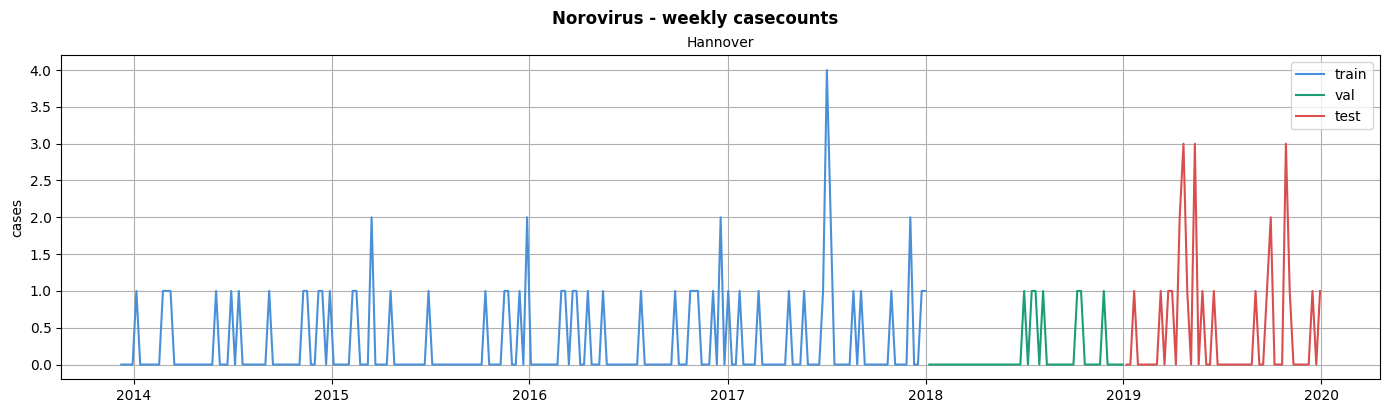

In [11]:
dataloader_hannover = data_orchestrator.preview(15, 'processed')
dataloader_hannover = (
    dataloader_hannover
        .labels.change_suptitle('Norovirus - weekly casecounts',fontweight='bold', fontsize=12)
        .labels.change_title('Hannover')
        .labels.set_suptitle_y(1.02)
        )
dataloader_hannover.show()

In [12]:
from src.dataloading import ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))





==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1381, val loss: 0.1712 ✓ (new best)
Epoch 11 train loss: 0.1359, val loss: 0.1688 (patience: 6/20)
Epoch 21 train loss: 0.1350, val loss: 0.1685 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
lr has been updated from 5.00e-05 to 2.50e-05
Epoch 31 train loss: 0.1357, val loss: 0.1686 (patience: 17/20)
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.1684
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 454.35it/s]

additonal transformation


Test loss: 0.1798
forecasted ✓

==                     gru                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1383, val loss: 0.1704 ✓ (new best)
Epoch 11 train loss: 0.1354, val loss: 0.1683 (patience: 4/20)
Epoch 21 train loss: 0.1353, val loss: 0.1683 (patience: 14/20)
lr has been updated from 1.00e-04 to 5.00e-05
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.1684
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 859.98it/s]

additonal transformation
Test loss: 0.1791
forecasted ✓


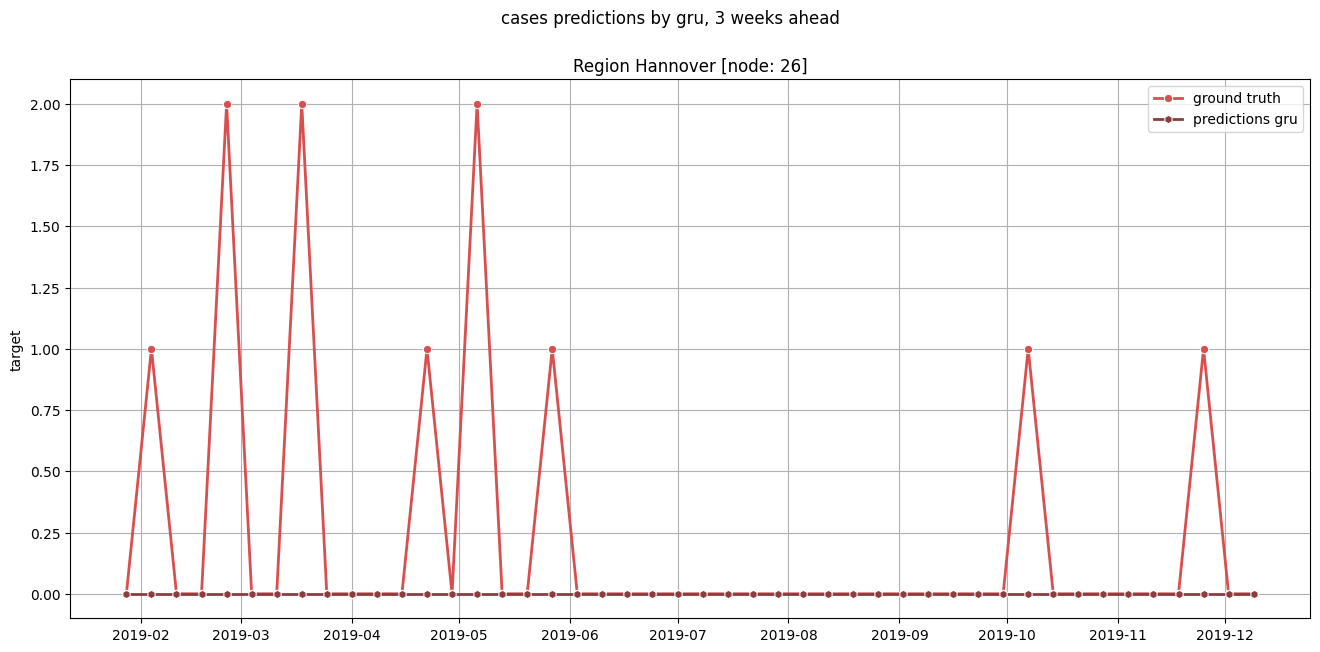

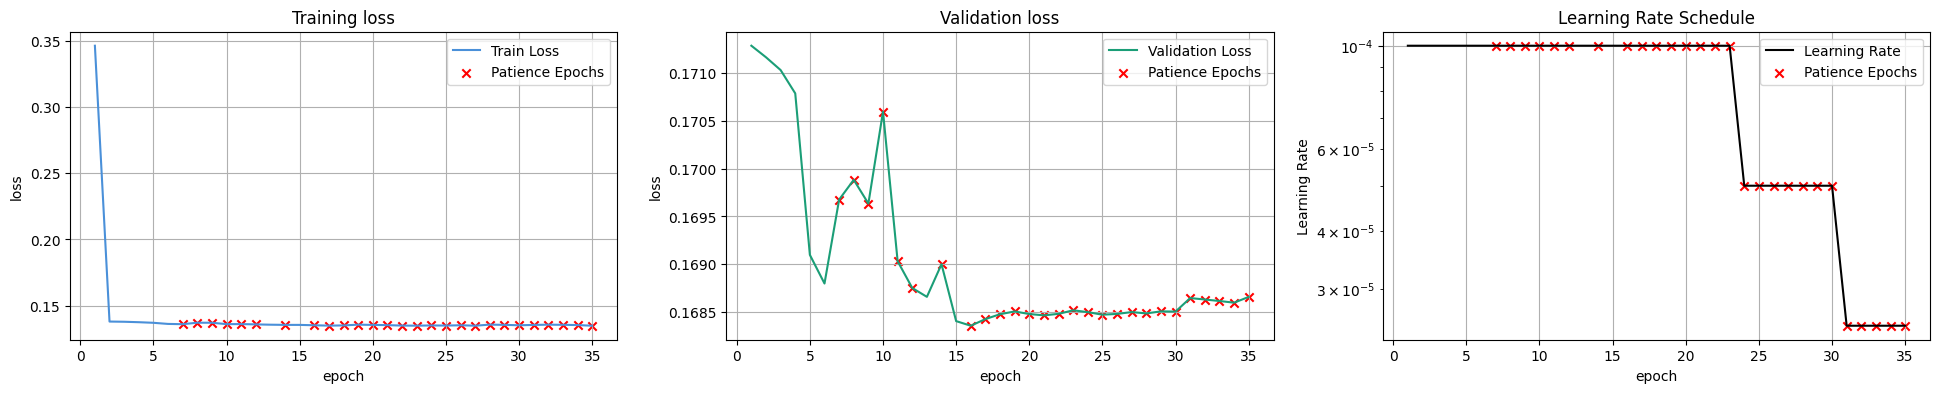

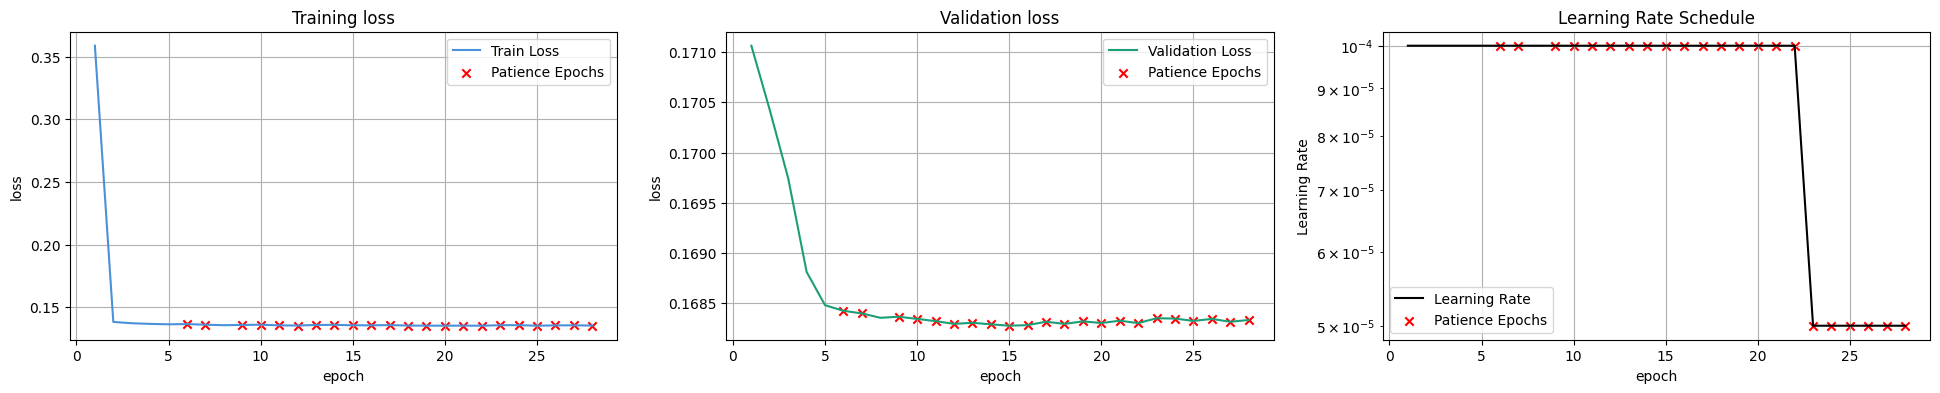

In [13]:
graphdataloader    = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


from src.models import NodeGRUModel, NodeLSTMModel

lstm = NodeLSTMModel(graphdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)

gru = NodeGRUModel(graphdataloader, name = 'gru', verbose = 2)
gru.set_model_hparams(hidden_size=128)
gru.set_global_hparams(**global_hparams)
gru.train()
gru.forecast('test')
gru.show_forecasts(26).show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.16it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

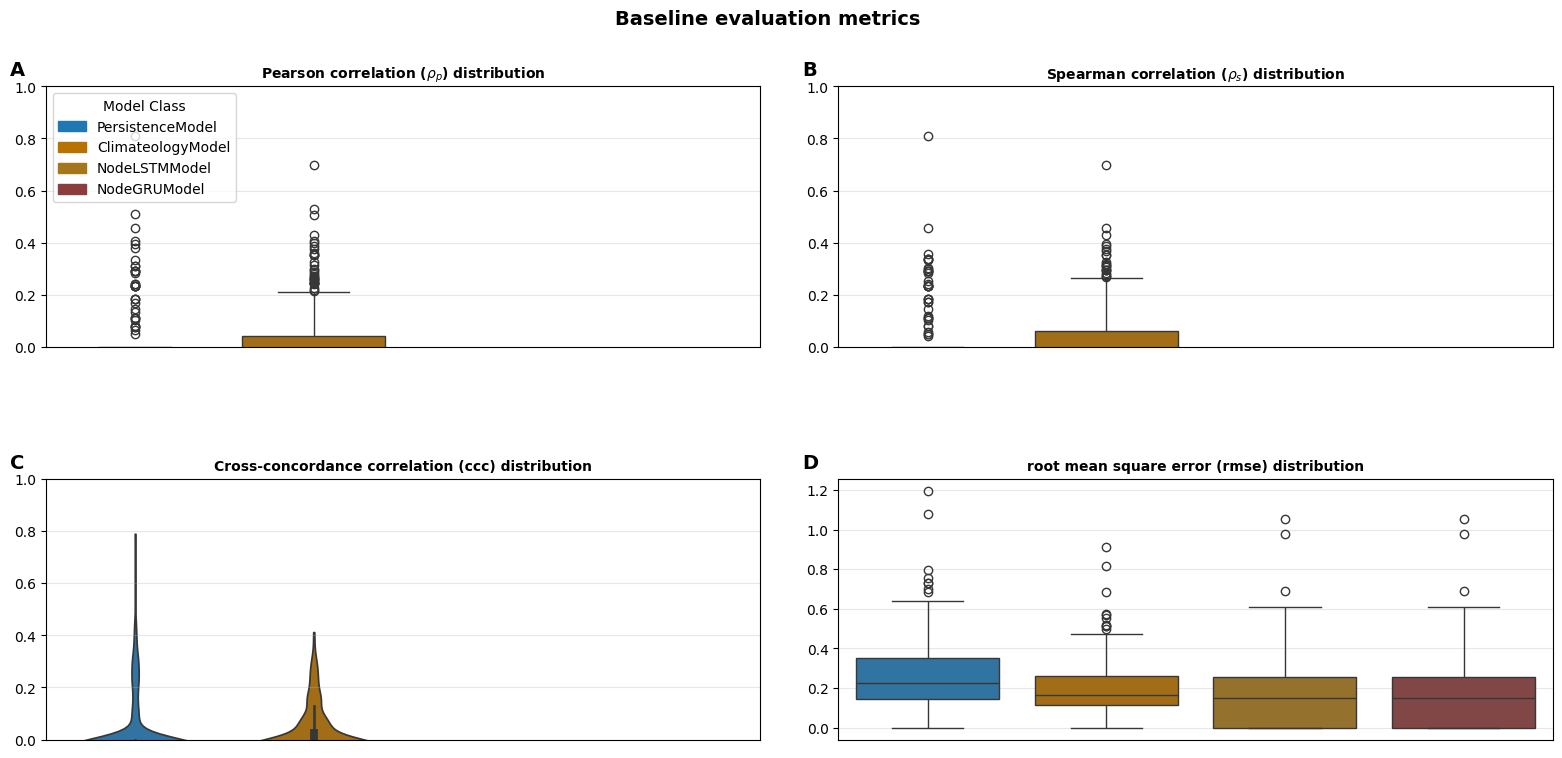

In [14]:
from src.evaluation import Evaluator
evaluation = Evaluator(models = [ps, cm, lstm, gru]).add_evaluation()
f_merged_raw    = evaluation.plotter.plot_metric_compilation(subfig_size = (8,4));

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Baseline evaluation metrics', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([])
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)             
    )
f_merged.show()